# Factor History Analysis

Copy `data/results_verification/factor_history.log` from the cluster to this repository (e.g., via `scp`) before running the cells below.

In [7]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
if not (repo_root / 'scripts').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib

try:
    matplotlib.use('module://matplotlib_inline.backend_inline')
except ValueError:
    matplotlib.use('nbagg')

import matplotlib.pyplot as plt

from scripts.factor_history_tools import (
    parse_factor_history,
    records_to_dataframe,
    add_absolute_capacities,
    plot_factor_trajectories,
    plot_cost_and_feasibility,
)

In [8]:
LOG_PATH = repo_root / 'data/results_verification/factor_history.log'
records = parse_factor_history(LOG_PATH)
print(f"Loaded {len(records)} records from {LOG_PATH}.")


Loaded 438 records from /Users/andreasmuhlbauer/Library/CloudStorage/OneDrive-Stanford/Research/JacobsonLab/2025LOADMATCH-PYTHON/loadmatch-python/data/results_verification/factor_history.log.


In [9]:
records_df = records_to_dataframe(records)
try:
    df = add_absolute_capacities(records_df, region="UNITED-STATES")
except FileNotFoundError:
    print("Supply file missing; falling back to multipliers only.")
    df = records_df


Supply file missing; falling back to multipliers only.


Absolute capacities unavailable (missing raw inputs); plotting multipliers instead.


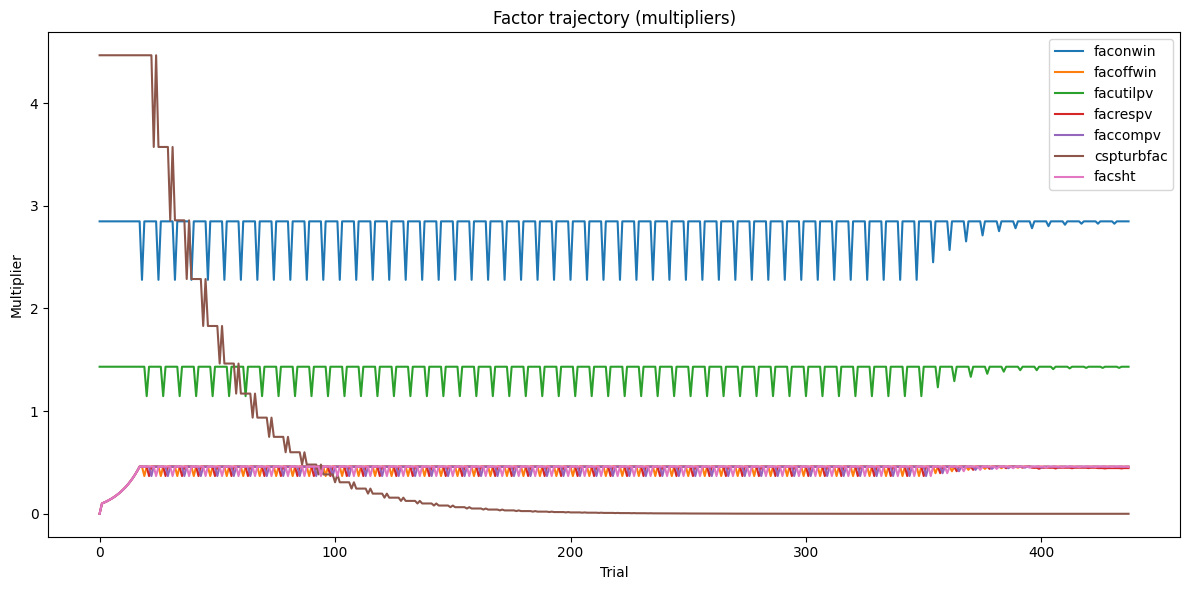

In [10]:
_ = plot_factor_trajectories(df, absolute=True)
plt.show()

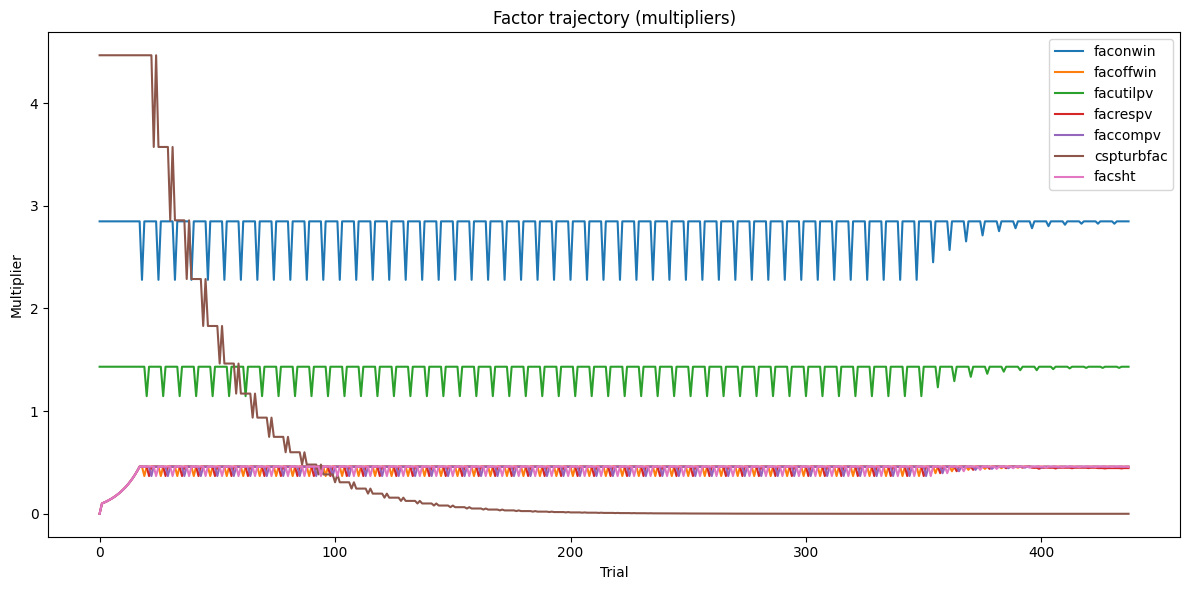

In [12]:
_ = plot_factor_trajectories(df, absolute=False)
plt.show()

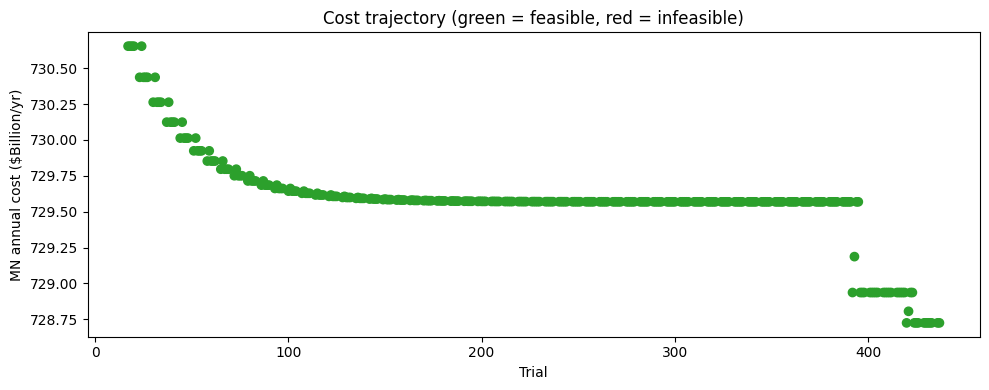

In [11]:
_ = plot_cost_and_feasibility(df)
plt.show()